<a href="https://colab.research.google.com/github/321222/Adventure_game/blob/main/Spotify_song.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

In [ ]:
df=pd.read_csv('rolling_stones_spotify.csv')
print(df.head())
print(df.info())

   Unnamed: 0                         name               album release_date  \
0           0   Concert Intro Music - Live  Licked Live In NYC   2022-06-10   
1           1   Street Fighting Man - Live  Licked Live In NYC   2022-06-10   
2           2           Start Me Up - Live  Licked Live In NYC   2022-06-10   
3           3  If You Can't Rock Me - Live  Licked Live In NYC   2022-06-10   
4           4            Don’t Stop - Live  Licked Live In NYC   2022-06-10   

   track_number                      id                                   uri  \
0             1  2IEkywLJ4ykbhi1yRQvmsT  spotify:track:2IEkywLJ4ykbhi1yRQvmsT   
1             2  6GVgVJBKkGJoRfarYRvGTU  spotify:track:6GVgVJBKkGJoRfarYRvGTU   
2             3  1Lu761pZ0dBTGpzxaQoZNW  spotify:track:1Lu761pZ0dBTGpzxaQoZNW   
3             4  1agTQzOTUnGNggyckEqiDH  spotify:track:1agTQzOTUnGNggyckEqiDH   
4             5  7piGJR8YndQBQWVXv6KtQw  spotify:track:7piGJR8YndQBQWVXv6KtQw   

   acousticness  danceability  energy 

In [ ]:
print(df.isnull().sum())
df=df.drop_duplicates()
df=df.fillna(df.mean(numeric_only=True))

Unnamed: 0          0
name                0
album               0
release_date        0
track_number        0
id                  0
uri                 0
acousticness        0
danceability        0
energy              0
instrumentalness    0
liveness            0
loudness            0
speechiness         0
tempo               0
valence             0
popularity          0
duration_ms         0
dtype: int64


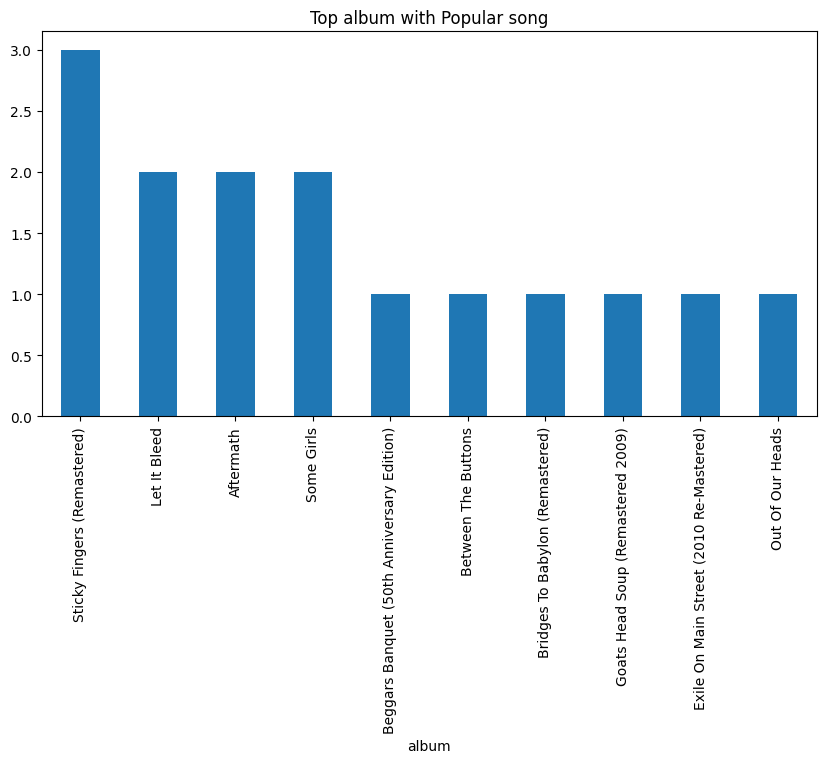

In [ ]:
popular_song=df[df['popularity']>60]
album_popularity=popular_song.groupby('album')['name'].count().sort_values(ascending=False)
plt.figure(figsize=(10,5))
album_popularity.head(10).plot(kind='bar')
plt.title("Top album with Popular song")
plt.show()

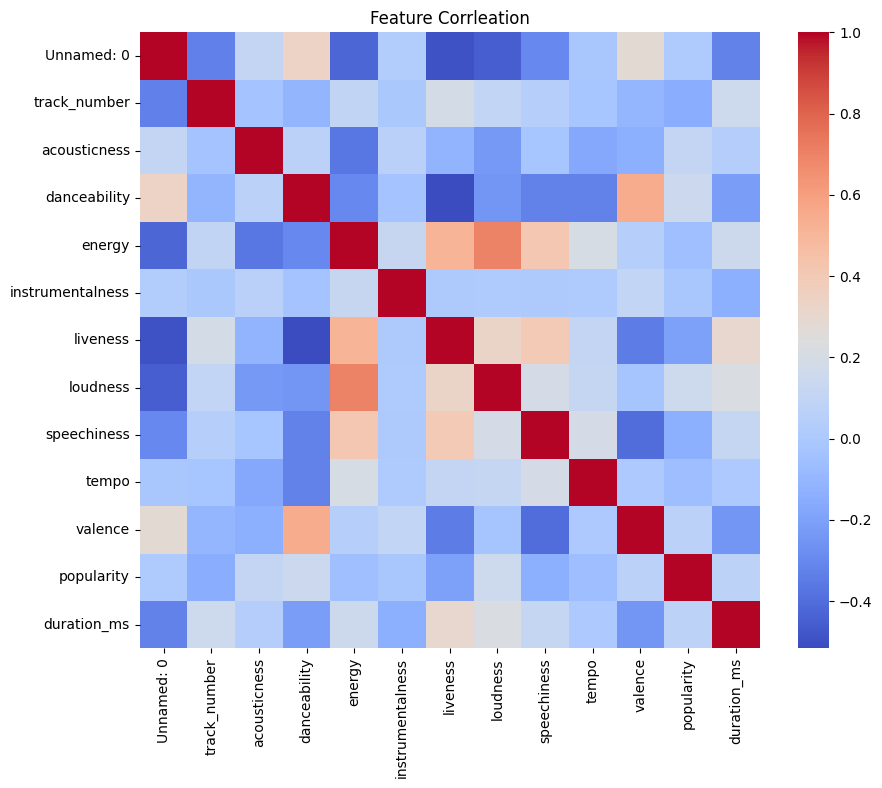

In [ ]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(numeric_only=True),annot=False,cmap='coolwarm')
plt.title("Feature Corrleation")
plt.show()

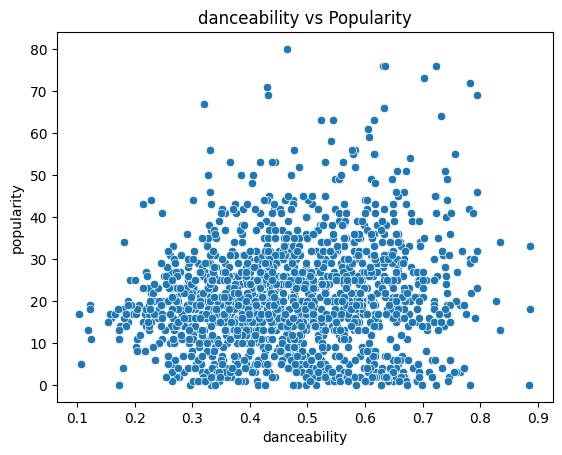

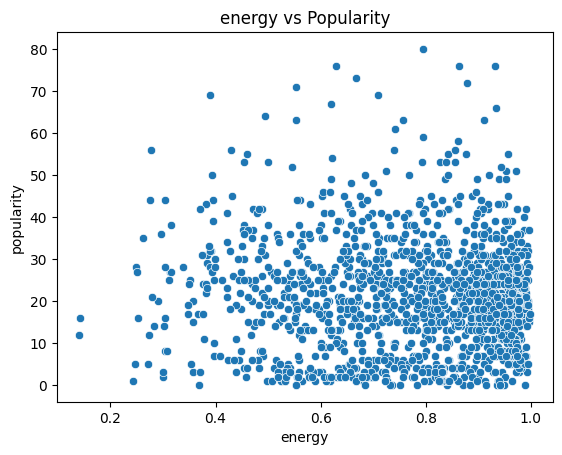

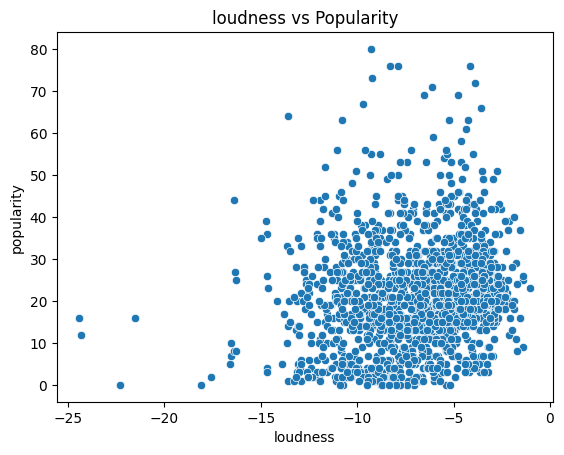

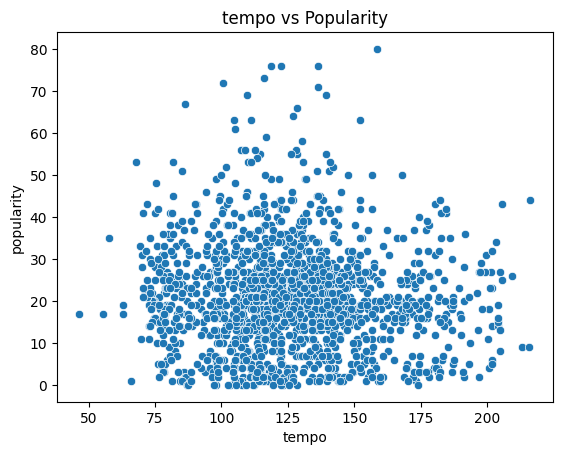

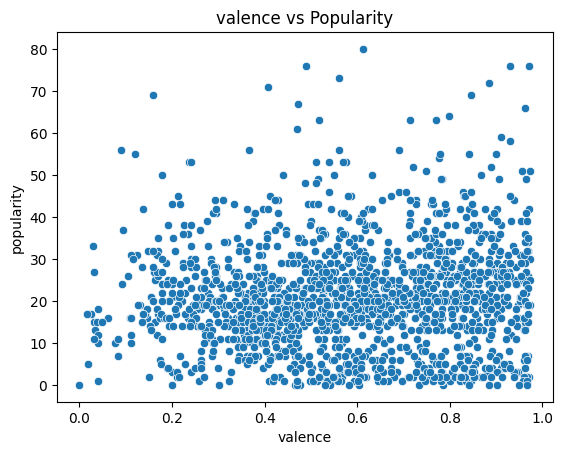

In [ ]:
features=['danceability','energy','loudness','tempo','valence']
for col in features:
  plt.figure()
  sns.scatterplot(x=df[col],y=df['popularity'])
  plt.title(f"{col} vs Popularity")
  plt.show()

In [ ]:
x=df[['danceability','energy','loudness','speechiness','acousticness','instrumentalness','liveness','valence','tempo']]

In [ ]:
import pandas as pd
from sklearn.preprocessing import StandardScaler

# Define and preprocess df to ensure it's available
df=pd.read_csv('rolling_stones_spotify.csv')
df=df.drop_duplicates()
df=df.fillna(df.mean(numeric_only=True))

scaler=StandardScaler()
x=df[['danceability','energy','loudness','speechiness','acousticness','instrumentalness','liveness','valence','tempo']]
X_scaled = scaler.fit_transform(x)

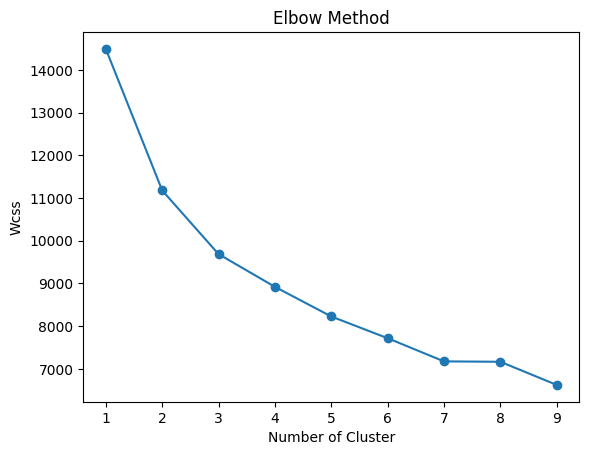

In [ ]:
wcss=[]
for i in range(1,10):
  kmeans= KMeans(n_clusters=i, random_state=42)
  kmeans.fit(X_scaled)
  wcss.append(kmeans.inertia_)
plt.plot(range(1,10),wcss,marker='o')
plt.xlabel('Number of Cluster')
plt.ylabel('Wcss')
plt.title('Elbow Method')
plt.show()

In [ ]:
k_means=KMeans(n_clusters=3,random_state=42)
df['Cluster'] = k_means.fit_predict(X_scaled)
df['Cluster'].value_counts()

,count
Cluster,
2,590
0,573
1,447


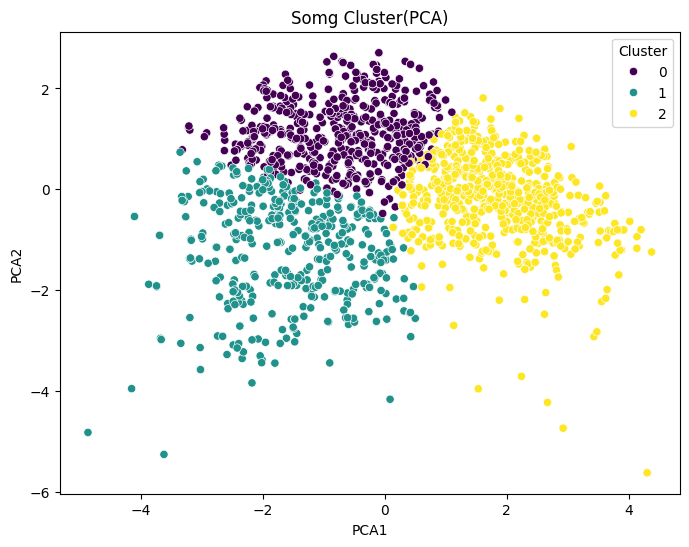

In [ ]:
df['Cluster'] = k_means.fit_predict(X_scaled)
x_pca = pca.fit_transform(X_scaled)
df['PCA1'] = x_pca[:, 0]
df['PCA2'] = x_pca[:, 1]

plt.figure(figsize=(8,6))
sns.scatterplot(x='PCA1',y='PCA2',hue='Cluster',data=df,palette='viridis')
plt.title("Somg Cluster(PCA)")
plt.show()

In [ ]:
cluster_summary=df.groupby('Cluster').mean(numeric_only=True)
print(cluster_summary)

          Unnamed: 0  track_number  acousticness  danceability    energy  \
Cluster                                                                    
0         877.244328      7.881326      0.182954      0.559689  0.828583   
1        1070.827740      7.722595      0.424293      0.496595  0.572110   
2         532.074576     10.000000      0.184361      0.359634  0.924027   

         instrumentalness  liveness  loudness  speechiness       tempo  \
Cluster                                                                  
0                0.228000  0.310290 -6.461913     0.048801  122.255513   
1                0.089431  0.285888 -9.725166     0.046628  115.282244   
2                0.158803  0.823893 -5.380466     0.106964  137.980510   

          valence  popularity    duration_ms      PCA1      PCA@      PCA0  \
Cluster                                                                      
0        0.785319   23.118674  229599.214660 -0.692217  1.147353 -0.692217   
1        0.499

In [ ]:
def recommmend_songs(cluster_id):
  return df[df['Cluster']==cluster_id][['name','album','popularity']].head(10)
print(recommmend_songs(0))

                                                 name  \
23     Honky Tonk Women - Live At The El Mocambo 1977   
25         Hand Of Fate - Live At The El Mocambo 1977   
26             Route 66 - Live At The El Mocambo 1977   
30          Crackin’ Up - Live At The El Mocambo 1977   
32    Around And Around - Live At The El Mocambo 1977   
33        Tumbling Dice - Live At The El Mocambo 1977   
34            Hot Stuff - Live At The El Mocambo 1977   
36  Let's Spend The Night Together - Live At The E...   
44               Luxury - Live At The El Mocambo 1977   
46                      Start Me Up - Remastered 2021   

                        album  popularity  
23     Live At The El Mocambo          32  
25     Live At The El Mocambo          29  
26     Live At The El Mocambo          30  
30     Live At The El Mocambo          27  
32     Live At The El Mocambo          27  
33     Live At The El Mocambo          32  
34     Live At The El Mocambo          27  
36     Live At The E

In [ ]:
from sklearn.cluster import DBSCAN
dbscan=DBSCAN(eps=1.5,min_samples=5)
df['DBSCAN_Cluster']= dbscan.fit_predict(X_scaled)
print(df['DBSCAN_Cluster'].value_counts())

DBSCAN_Cluster
 0    1412
-1     187
 2       5
 1       5
 3       1
Name: count, dtype: int64


In [ ]:
import plotly.express as px
fig=px.scatter(
    df, x='PCA1', y='PCA2', color='DBSCAN_Cluster',
    title='DBSCAN CLUSTERING'
)
fig.show()

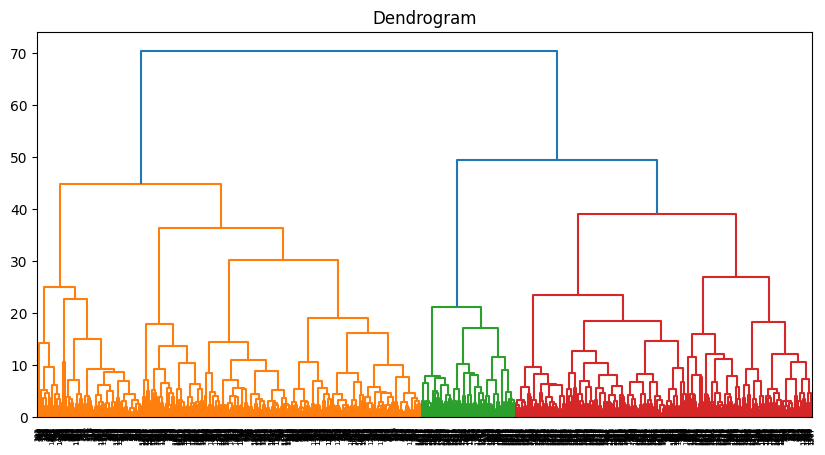

In [ ]:
from scipy.cluster.hierarchy import dendrogram,linkage
from sklearn.cluster import AgglomerativeClustering
linked=linkage(X_scaled,method='ward')
plt.figure(figsize=(10,5))
dendrogram(linked)
plt.title("Dendrogram")
plt.show()

In [37]:
hc = AgglomerativeClustering(n_clusters=3)
df['HC_CLuster'] = hc.fit_predict(X_scaled)
print(df['HC_CLuster'].value_counts())

HC_CLuster
0    798
1    616
2    196
Name: count, dtype: int64


In [41]:
fig=px.scatter(
    df,x='PCA1',y='PCA2',color='HC_CLuster',
    title='Hierarchical Clustering'
)
fig.show()

In [42]:
album_popularity=df.groupby('album')['popularity'].mean().sort_values(ascending=False)
fig=px.bar(
    album_popularity.head(10),
    title='Top Album popularity',
    labels=('values:Popluarity','indes:album')
)
fig.show()

In [43]:
fig = px.scatter_3d(
    df,
    x='energy',
    y='danceability',
    z='valence',
    color='Cluster',
    title="3D Song Clusters"
)
fig.show()

In [44]:
fig = px.histogram(
    df, x='energy',
    nbins=30,
    title="Energy Distribution"
)
fig.show()

In [45]:
fig = px.scatter(
    df,
    x='danceability',
    y='popularity',
    color='Cluster',
    hover_data=['name','album'],
    title="Danceability vs Popularity"
)
fig.show()